In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings

In [2]:
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('muted')


In [3]:
train = pd.read_csv('data/train.csv')
test  = pd.read_csv('data/test.csv')

print(f'Train: {train.shape[0]} strings, {train.shape[1]} columns')
print(f'Test:  {test.shape[0]} strings, {test.shape[1]} columns')

Train: 1460 strings, 81 columns
Test:  1459 strings, 80 columns


In [4]:
train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [5]:
train.dtypes.value_counts()

object     43
int64      35
float64     3
Name: count, dtype: int64

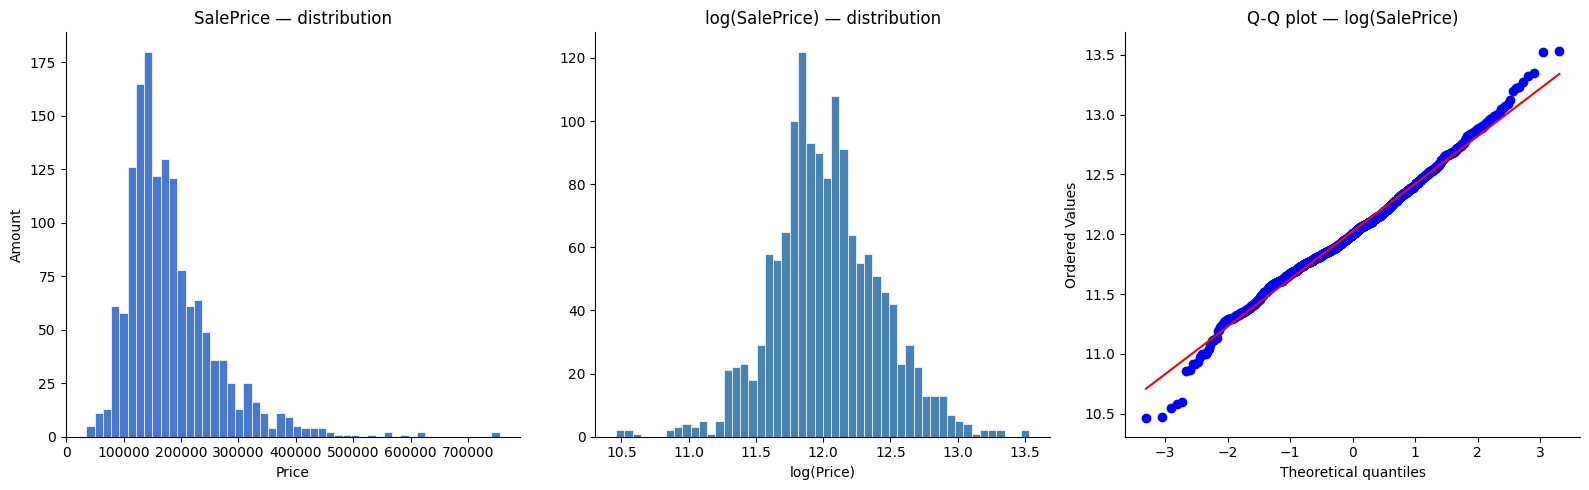

Skewness (original):       1.883
Skewness (log-transform):  0.121
Kurtosis (original):       6.536

Statistics:
count      $1,460
mean     $180,921
std       $79,443
min       $34,900
25%      $129,975
50%      $163,000
75%      $214,000
max      $755,000
Name: SalePrice, dtype: object


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# hist
axes[0].hist(train['SalePrice'], bins=50, edgecolor='white', linewidth=0.5)
axes[0].set_title('SalePrice — distribution')
axes[0].set_xlabel('Price')
axes[0].set_ylabel('Amount')

# Log-transformation
log_price = np.log1p(train['SalePrice'])
axes[1].hist(log_price, bins=50, edgecolor='white', linewidth=0.5, color='steelblue')
axes[1].set_title('log(SalePrice) — distribution')
axes[1].set_xlabel('log(Price)')

# Q-Q plot for log
stats.probplot(log_price, dist='norm', plot=axes[2])
axes[2].set_title('Q-Q plot — log(SalePrice)')

plt.tight_layout()
plt.show()

print(f'Skewness (original):       {train["SalePrice"].skew():.3f}')
print(f'Skewness (log-transform):  {log_price.skew():.3f}')
print(f'Kurtosis (original):       {train["SalePrice"].kurt():.3f}')
print(f'\nStatistics:')
print(train['SalePrice'].describe().apply(lambda x: f'${x:,.0f}'))

**Conclusion:** `SalePrice` exhibits right-skewed distribution (skew > 1). After a log transformation, the distribution becomes close to normal—we will use `log1p(SalePrice)` as the target variable during training

In [7]:
def missing_summary(df, name='DataFrame'):
    missing = df.isnull().sum()
    missing = missing[missing > 0].sort_values(ascending=False)
    pct = (missing / len(df) * 100).round(2)
    result = pd.DataFrame({'Missing': missing, '% of total': pct})
    print(f'\n{name}: {len(missing)} columns with mossing data')
    return result

train_missing = missing_summary(train, 'TRAIN')
train_missing


TRAIN: 19 columns with mossing data


,Missing,% of total
PoolQC,1453,99.52
MiscFeature,1406,96.30
Alley,1369,93.77
Fence,1179,80.75
MasVnrType,872,59.73
FireplaceQu,690,47.26
LotFrontage,259,17.74
GarageType,81,5.55
GarageYrBlt,81,5.55
GarageFinish,81,5.55


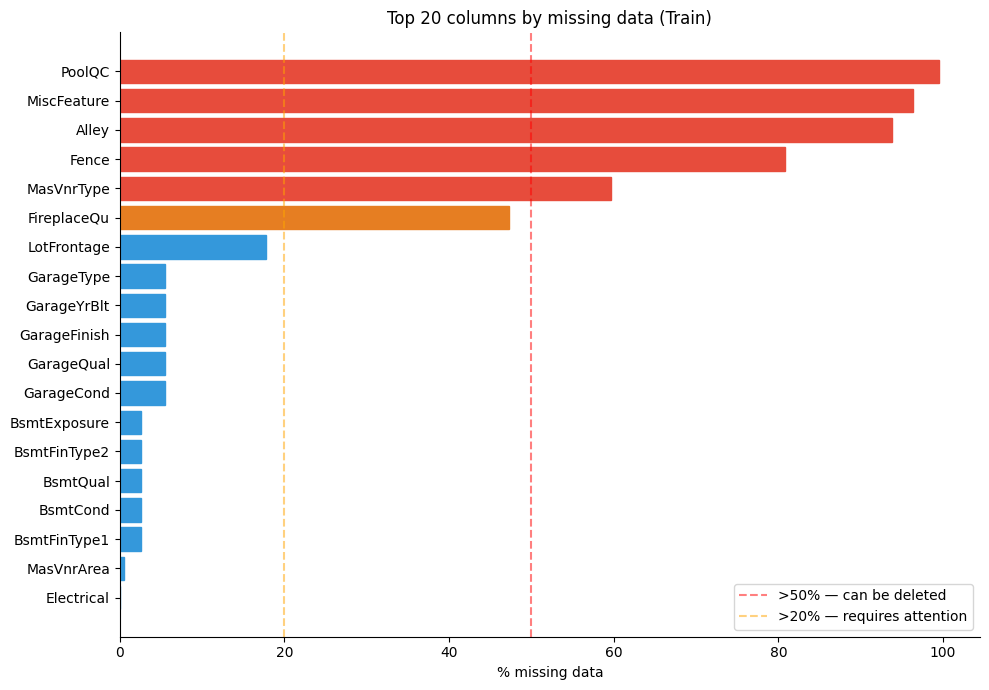

In [8]:
top_missing = train_missing.head(20)

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(top_missing.index[::-1], top_missing['% of total'][::-1])

# Color by transparency level
for bar, pct in zip(bars, top_missing['% of total'][::-1]):
    if pct > 50:
        bar.set_color('#e74c3c')
    elif pct > 20:
        bar.set_color('#e67e22')
    else:
        bar.set_color('#3498db')

ax.axvline(x=50, color='red', linestyle='--', alpha=0.5, label='>50% — can be deleted')
ax.axvline(x=20, color='orange', linestyle='--', alpha=0.5, label='>20% — requires attention')
ax.set_xlabel('% missing data')
ax.set_title('Top 20 columns by missing data (Train)')
ax.legend()
plt.tight_layout()
plt.show()

In [9]:
none_meaning_cols = [
    'Alley',       # no alley
    'BsmtQual',    # no basement
    'BsmtCond',
    'BsmtExposure',
    'BsmtFinType1',
    'BsmtFinType2',
    'FireplaceQu', # no fireplace
    'GarageType',  # no garage
    'GarageFinish',
    'GarageQual',
    'GarageCond',
    'PoolQC',      # no pool
    'Fence',       # no fence
    'MiscFeature', # no add. objects
    'MasVnrType',  # no cladding
]

print('Columns where NaN = "no object":')
for col in none_meaning_cols:
    if col in train.columns:
        n = train[col].isnull().sum()
        print(f'  {col:20s}: {n} Missing ({n/len(train)*100:.1f}%)')

Columns where NaN = "no object":
  Alley               : 1369 Missing (93.8%)
  BsmtQual            : 37 Missing (2.5%)
  BsmtCond            : 37 Missing (2.5%)
  BsmtExposure        : 38 Missing (2.6%)
  BsmtFinType1        : 37 Missing (2.5%)
  BsmtFinType2        : 38 Missing (2.6%)
  FireplaceQu         : 690 Missing (47.3%)
  GarageType          : 81 Missing (5.5%)
  GarageFinish        : 81 Missing (5.5%)
  GarageQual          : 81 Missing (5.5%)
  GarageCond          : 81 Missing (5.5%)
  PoolQC              : 1453 Missing (99.5%)
  Fence               : 1179 Missing (80.8%)
  MiscFeature         : 1406 Missing (96.3%)
  MasVnrType          : 872 Missing (59.7%)


In [10]:
num_cols = train.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c not in ['Id', 'SalePrice']]
print(f'Amount of features: {len(num_cols)}')
print(num_cols)

Amount of features: 36
['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold']


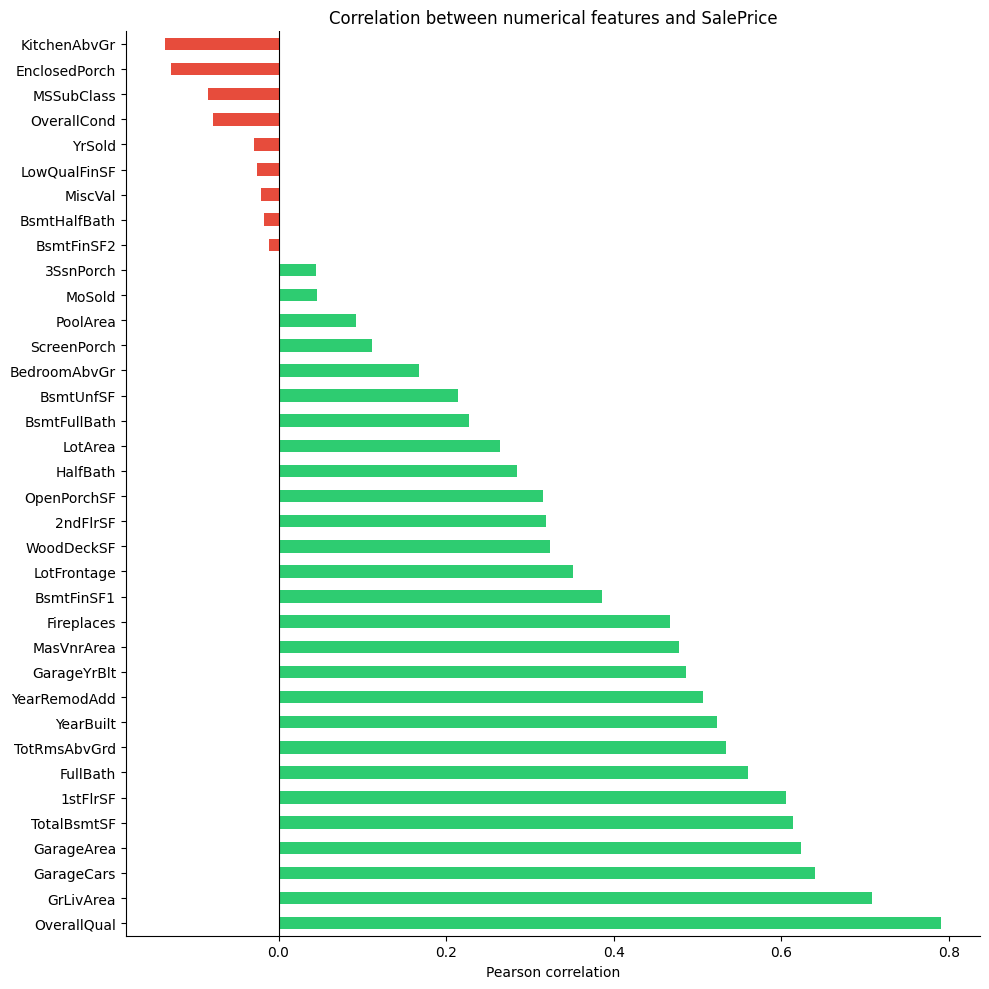

In [11]:
corr_with_target = (
    train[num_cols + ['SalePrice']]
    .corr()['SalePrice']
    .drop('SalePrice')
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(10, 10))
colors = ['#2ecc71' if x > 0 else '#e74c3c' for x in corr_with_target]
corr_with_target.plot(kind='barh', ax=ax, color=colors)
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_title('Correlation between numerical features and SalePrice')
ax.set_xlabel('Pearson correlation')
plt.tight_layout()
plt.show()

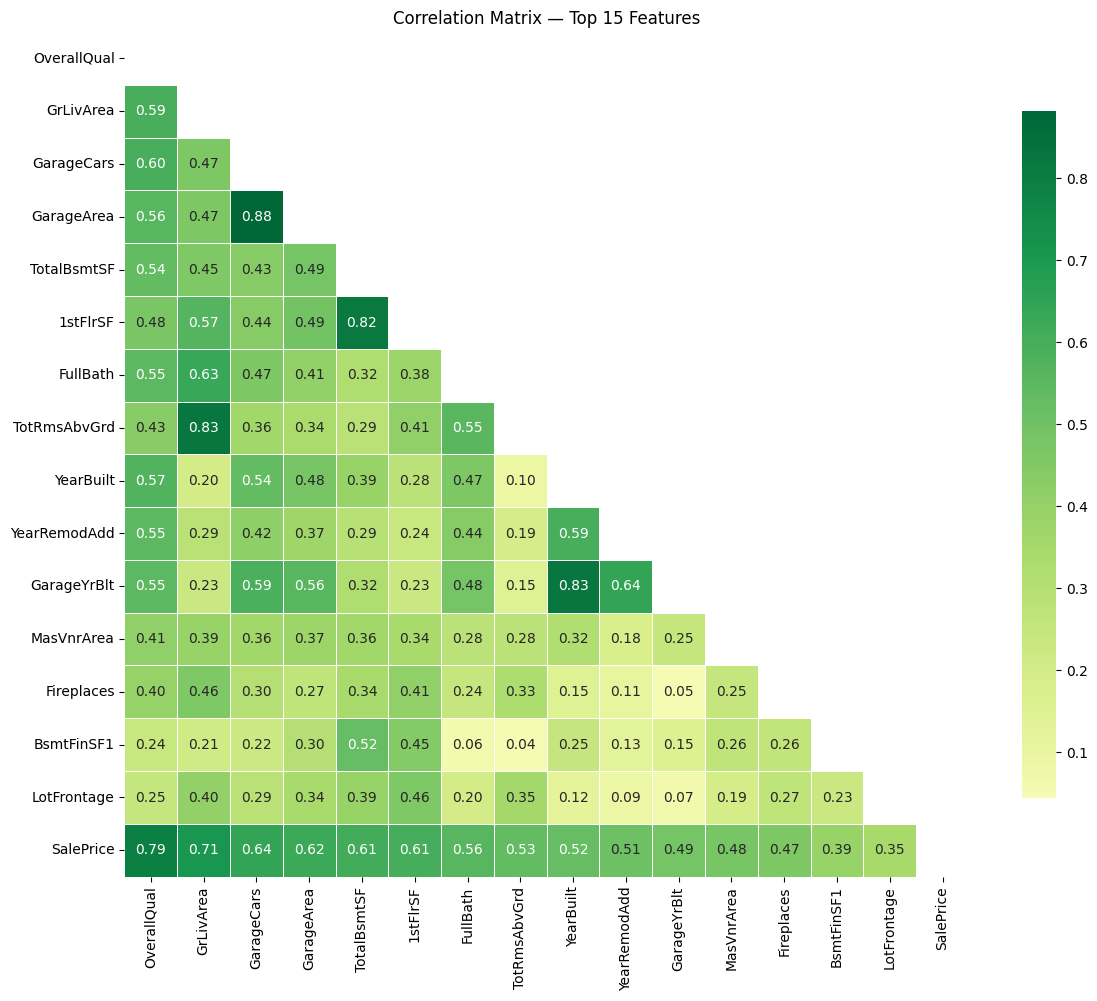

In [12]:
top15_cols = corr_with_target.abs().sort_values(ascending=False).head(15).index.tolist()
top15_cols.append('SalePrice')

corr_matrix = train[top15_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlGn', center=0, square=True,
    linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8}
)
ax.set_title('Correlation Matrix — Top 15 Features')
plt.tight_layout()
plt.show()

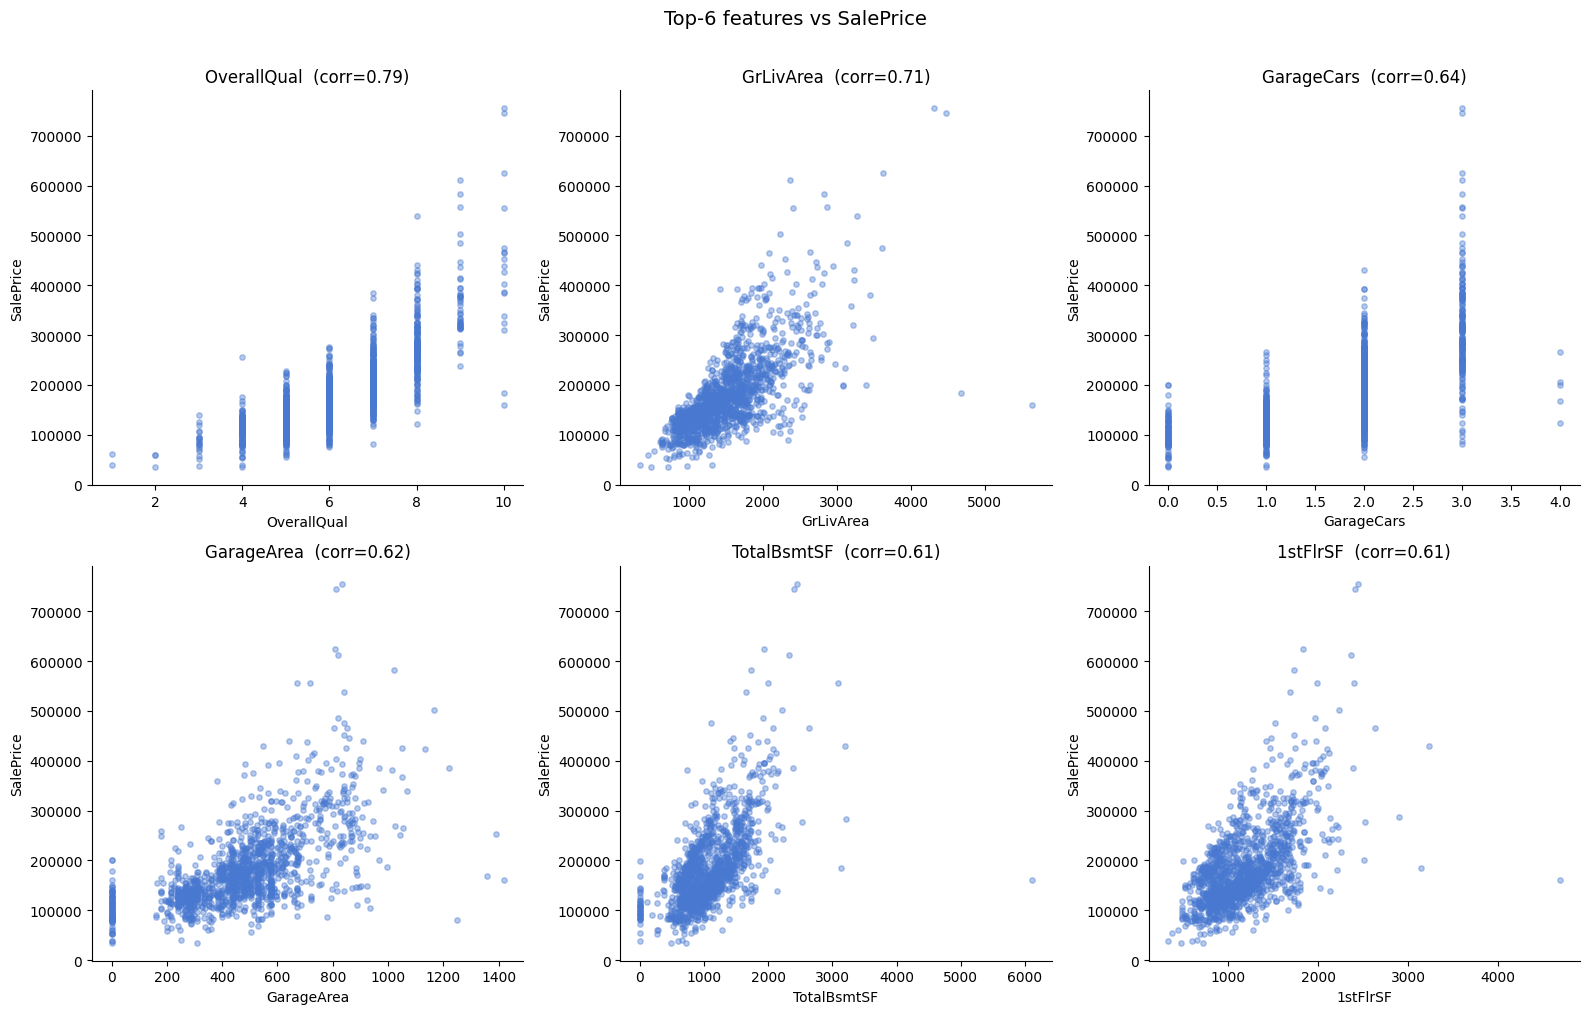

In [13]:
top6 = corr_with_target.head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(top6):
    axes[i].scatter(train[col], train['SalePrice'], alpha=0.4, s=15)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('SalePrice')
    axes[i].set_title(f'{col}  (corr={corr_with_target[col]:.2f})')

plt.suptitle('Top-6 features vs SalePrice', y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

Features with |skew| > 0.75: 21


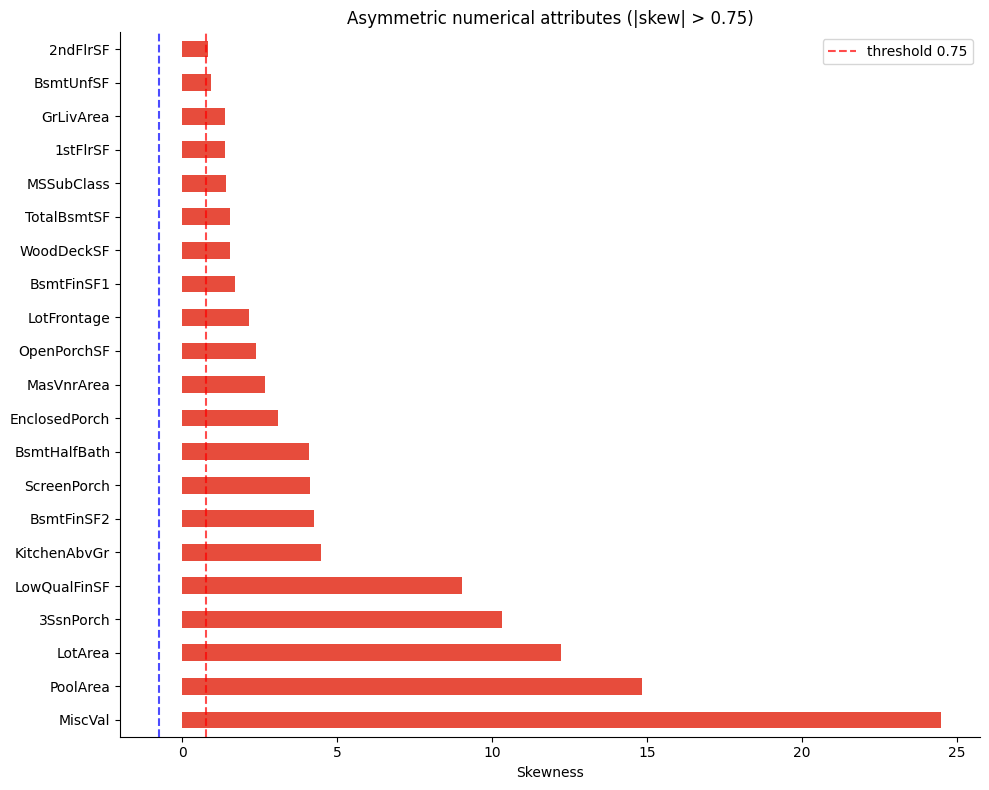

In [14]:
# Asymmetry in numerical attributes (needs to be corrected during FE)
skewness = train[num_cols].apply(lambda x: x.dropna().skew()).sort_values(ascending=False)
skewed = skewness[skewness.abs() > 0.75]

print(f'Features with |skew| > 0.75: {len(skewed)}')

fig, ax = plt.subplots(figsize=(10, 8))
skewed.plot(kind='barh', ax=ax, color=['#e74c3c' if x > 0 else '#3498db' for x in skewed])
ax.axvline(x=0.75, color='red', linestyle='--', alpha=0.7, label='threshold 0.75')
ax.axvline(x=-0.75, color='blue', linestyle='--', alpha=0.7)
ax.set_title('Asymmetric numerical attributes (|skew| > 0.75)')
ax.set_xlabel('Skewness')
ax.legend()
plt.tight_layout()
plt.show()

In [15]:
cat_cols = train.select_dtypes(include=['object']).columns.tolist()
print(f'Categorical characteristics: {len(cat_cols)}')
print(cat_cols)

Categorical characteristics: 43
['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondition']


In [16]:
cat_unique = pd.DataFrame({
    'Unique values': train[cat_cols].nunique(),
    'Passes': train[cat_cols].isnull().sum()
}).sort_values('Unique values', ascending=False)

cat_unique

,Unique values,Passes
Neighborhood,25,0
Exterior2nd,16,0
Exterior1st,15,0
Condition1,9,0
SaleType,9,0
HouseStyle,8,0
RoofMatl,8,0
Condition2,8,0
Functional,7,0
BsmtFinType2,6,38


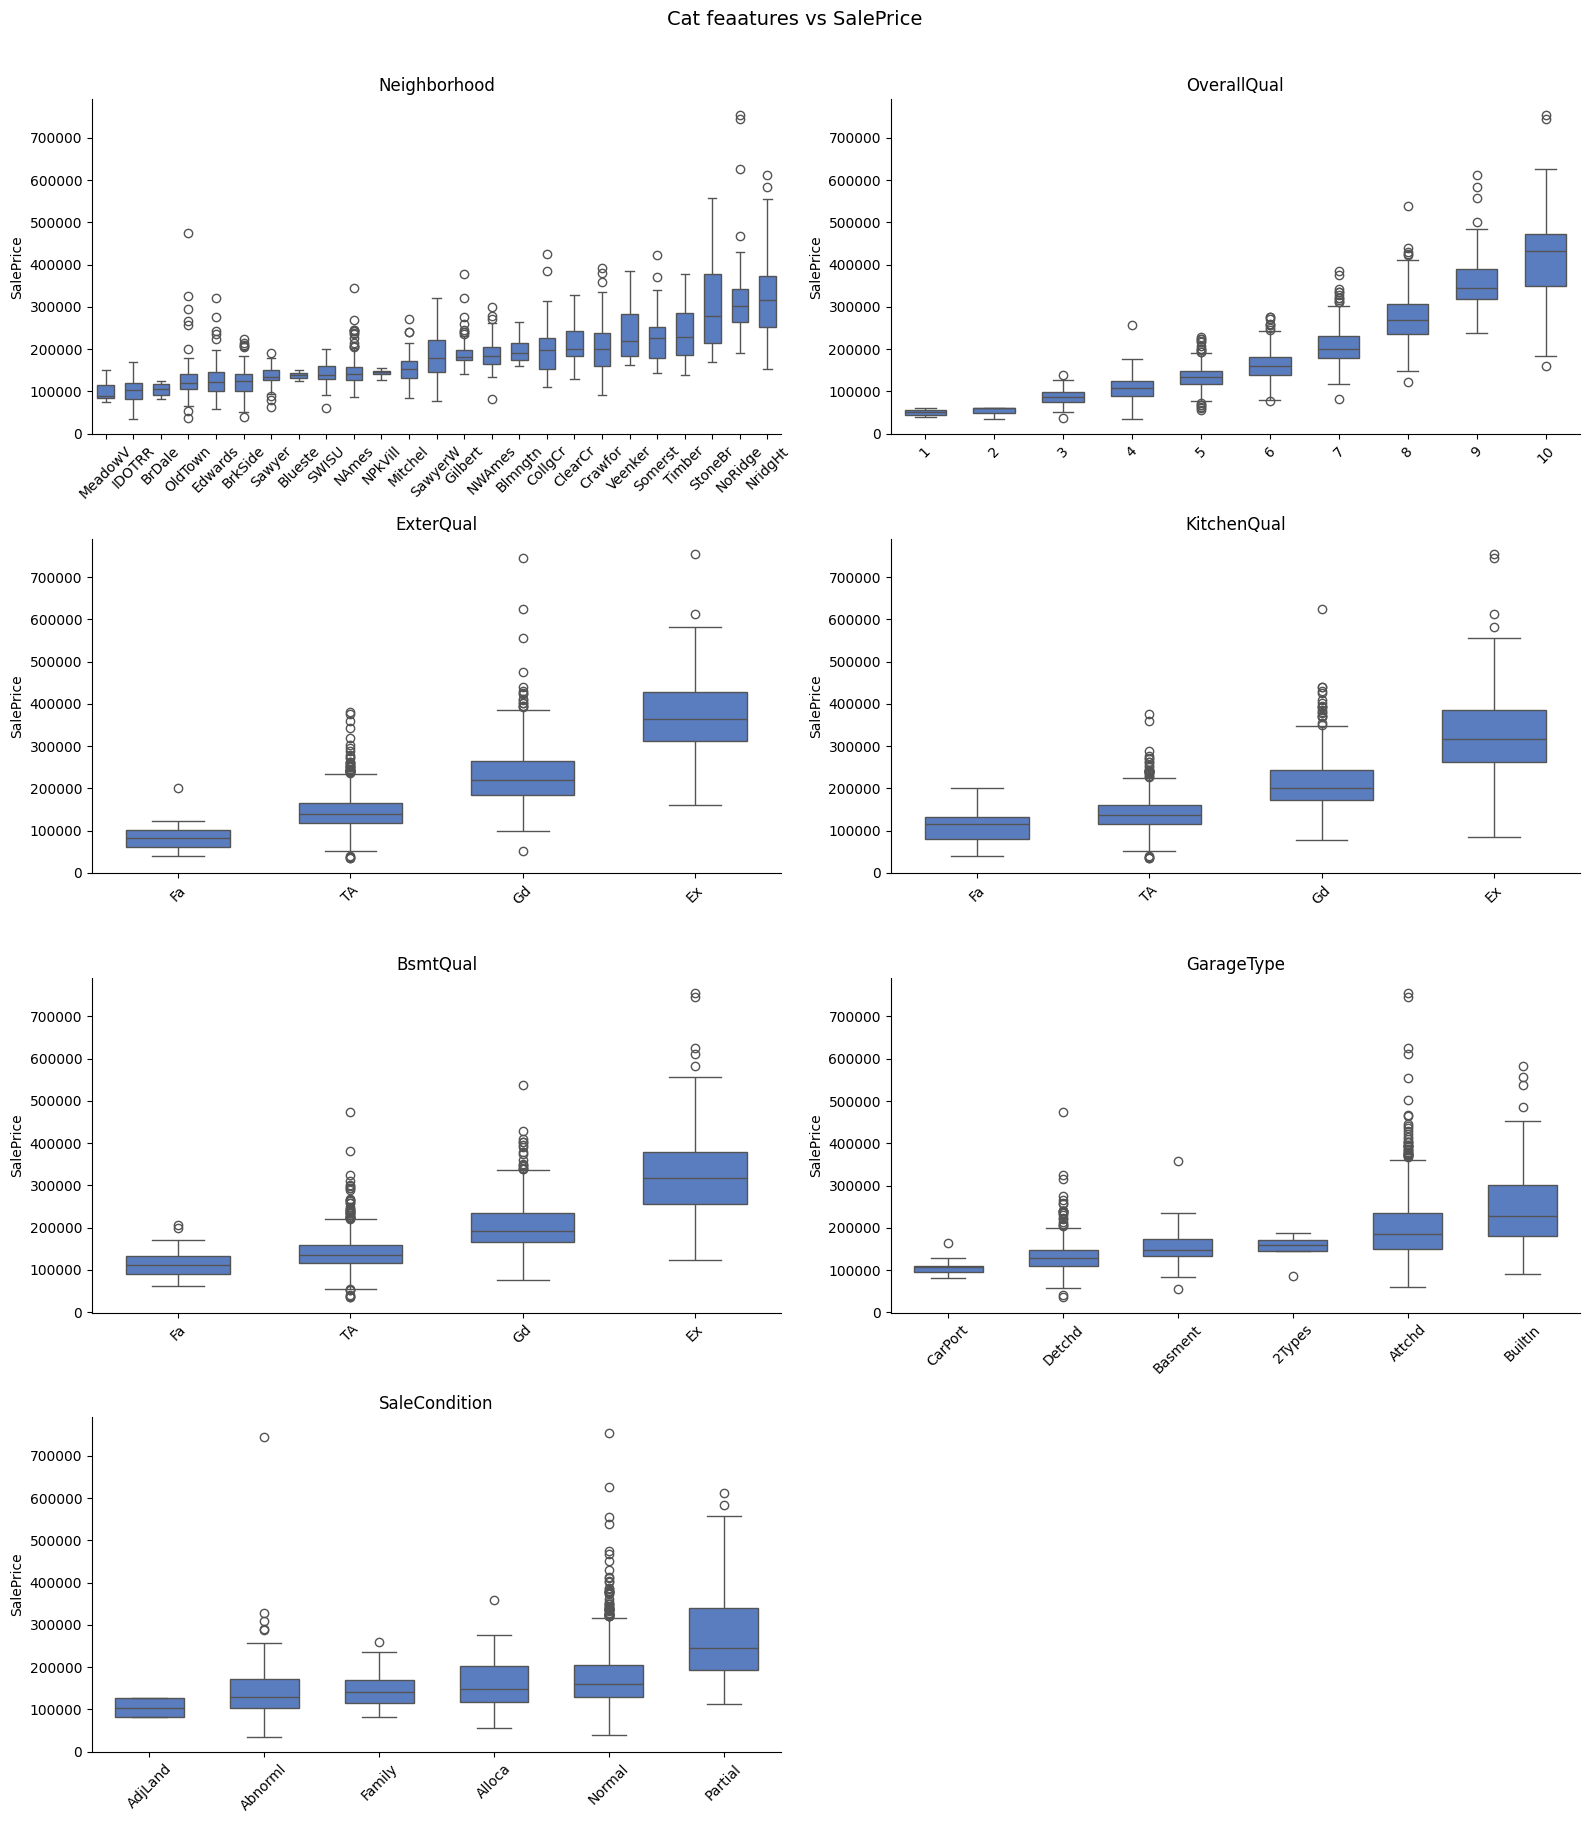

In [17]:
key_cat = ['Neighborhood', 'OverallQual', 'ExterQual', 'KitchenQual',
           'BsmtQual', 'GarageType', 'SaleCondition']

# OverallQual 
train['OverallQual'] = train['OverallQual'].astype(str)

fig, axes = plt.subplots(4, 2, figsize=(16, 18))
axes = axes.flatten()

for i, col in enumerate(key_cat):
    if col in train.columns:
        order = train.groupby(col)['SalePrice'].median().sort_values().index
        sns.boxplot(data=train, x=col, y='SalePrice', order=order,
                    ax=axes[i], width=0.6)
        axes[i].set_title(col)
        axes[i].set_xlabel('')
        axes[i].tick_params(axis='x', rotation=45)

if len(key_cat) < len(axes):
    for j in range(len(key_cat), len(axes)):
        fig.delaxes(axes[j])

train['OverallQual'] = train['OverallQual'].astype(int)

plt.suptitle('Cat feaatures vs SalePrice', y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

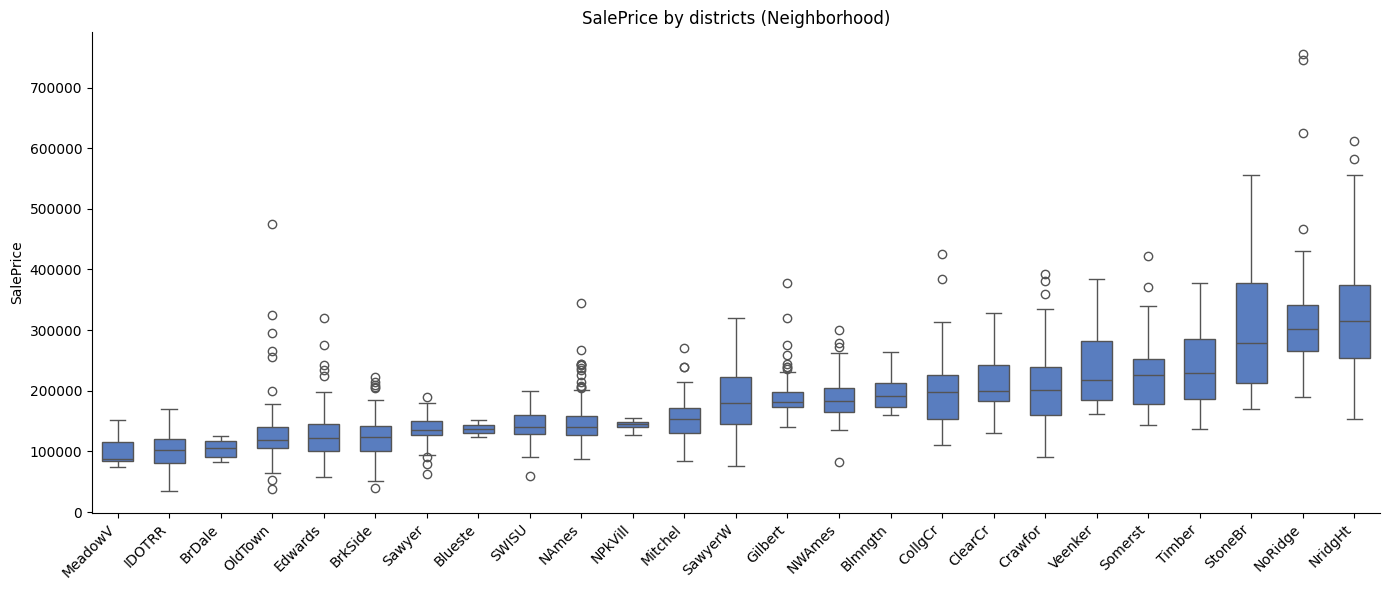

In [18]:
fig, ax = plt.subplots(figsize=(14, 6))
order = train.groupby('Neighborhood')['SalePrice'].median().sort_values().index
sns.boxplot(data=train, x='Neighborhood', y='SalePrice', order=order, ax=ax, width=0.6)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_title('SalePrice by districts (Neighborhood)')
ax.set_xlabel('')
plt.tight_layout()
plt.show()

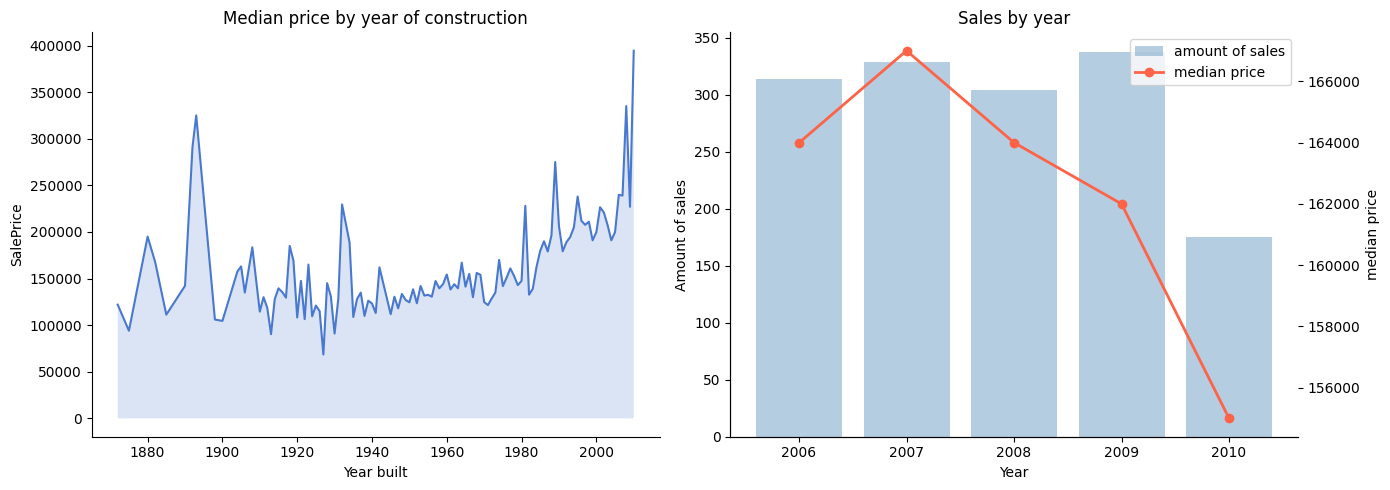

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

year_price = train.groupby('YearBuilt')['SalePrice'].median()
axes[0].plot(year_price.index, year_price.values, linewidth=1.5)
axes[0].fill_between(year_price.index, year_price.values, alpha=0.2)
axes[0].set_title('Median price by year of construction')
axes[0].set_xlabel('Year built')
axes[0].set_ylabel('SalePrice')

# Год продажи
year_sold = train.groupby('YrSold')['SalePrice'].agg(['median', 'count'])
ax2 = axes[1].twinx()
axes[1].bar(year_sold.index, year_sold['count'], alpha=0.4, color='steelblue', label='amount of sales')
ax2.plot(year_sold.index, year_sold['median'], color='tomato', marker='o', linewidth=2, label='median price')
axes[1].set_title('Sales by year')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Amount of sales')
ax2.set_ylabel('median price')
lines1, labels1 = axes[1].get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
axes[1].legend(lines1 + lines2, labels1 + labels2)

plt.tight_layout()
plt.show()

Potential outliers (GrLivArea>4000 и SalePrice<300k): 2
      GrLivArea  SalePrice Neighborhood  OverallQual
523        4676     184750      Edwards           10
1298       5642     160000      Edwards           10


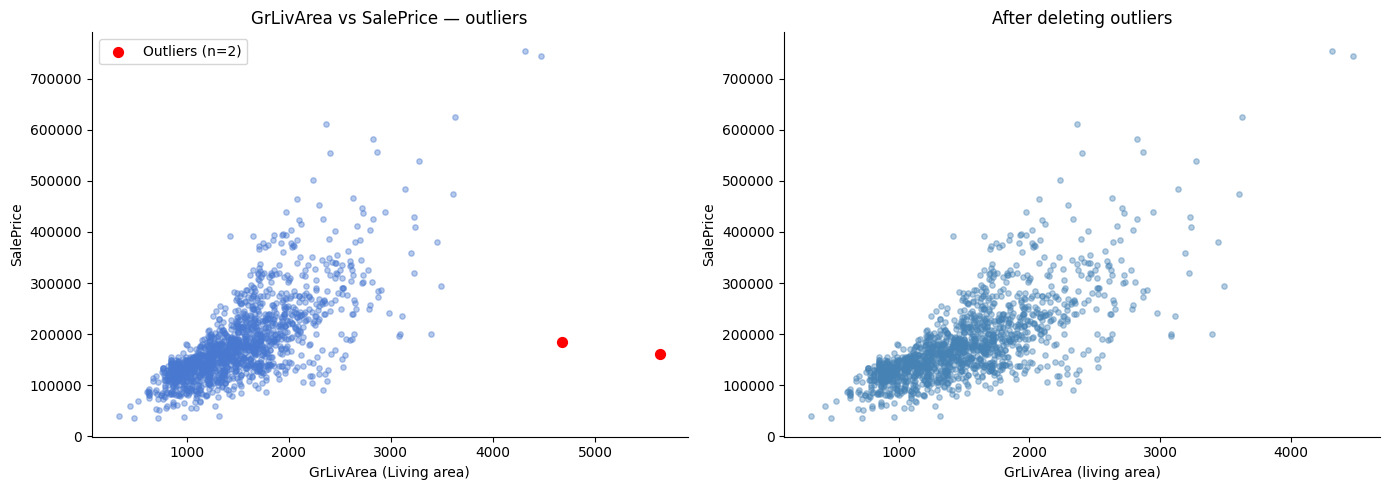

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(train['GrLivArea'], train['SalePrice'], alpha=0.4, s=15)
axes[0].set_xlabel('GrLivArea (Living area)')
axes[0].set_ylabel('SalePrice')
axes[0].set_title('GrLivArea vs SalePrice — outliers')

# Highlight outliers
outliers = train[(train['GrLivArea'] > 4000) & (train['SalePrice'] < 300000)]
axes[0].scatter(outliers['GrLivArea'], outliers['SalePrice'],
                color='red', s=50, zorder=5, label=f'Outliers (n={len(outliers)})')
axes[0].legend()

print(f'Potential outliers (GrLivArea>4000 и SalePrice<300k): {len(outliers)}')
print(outliers[['GrLivArea', 'SalePrice', 'Neighborhood', 'OverallQual']])

# После удаления
train_clean = train.drop(outliers.index)
axes[1].scatter(train_clean['GrLivArea'], train_clean['SalePrice'], alpha=0.4, s=15, color='steelblue')
axes[1].set_xlabel('GrLivArea (living area)')
axes[1].set_ylabel('SalePrice')
axes[1].set_title('After deleting outliers')

plt.tight_layout()
plt.show()

In [21]:
z_scores = np.abs(stats.zscore(train[num_cols].fillna(train[num_cols].median())))
outlier_mask = (z_scores > 3).any(axis=1)
print(f'Rows with a z-score greater than 3 for at least one characteristic: {outlier_mask.sum()} ({outlier_mask.mean()*100:.1f}%)')

Rows with a z-score greater than 3 for at least one characteristic: 439 (30.1%)


In [22]:
print('=' * 60)
print('EDA RESULTS — FUTURE OF PROJECT')
print('=' * 60)

print('''
 TARGET VARIABLE
  → Use np.log1p(SalePrice) during training
  → After prediction: np.expm1(y_pred)

 MISSING VALUES
  → NaN in ‘None-meaning’ columns (PoolQC, Fence, etc.) → fill with “None” / 0
  → LotFrontage → fill with the median by Neighborhood
  → GarageYrBlt → fill with YearBuilt
  → MasVnrArea → fill with 0
  → Electrical (1 missing value) → fill with mode

 OUTLIES
  → Remove 2 records: GrLivArea > 4000 AND SalePrice < 300k

 NEW FEATURES (ideas)
  → TotalSF = TotalBsmtSF + 1stFlrSF + 2ndFlrSF
  → TotalBath = FullBath + 0.5*HalfBath + BsmtFullBath + 0.5*BsmtHalfBath
  → HouseAge = YrSold - YearBuilt
  → RemodAge = YrSold - YearRemodAdd
  → IsRemodeled = (YearBuilt != YearRemodAdd).astype(int)
  → HasPool = (PoolArea > 0).astype(int)
  → HasGarage = (GarageArea > 0).astype(int)
  → HasFireplace = (Fireplaces > 0).astype(int)

 TRANSFORMATIONS
  → Box-Cox / log1p for features with |skew| > 0.75

 ENCODING
  → Label Encoding for ordinal features (ExterQual, KitchenQual, BsmtQual, ...)
  → One-Hot Encoding for the remaining categories
''')

EDA RESULTS — FUTURE OF PROJECT

 TARGET VARIABLE
  → Use np.log1p(SalePrice) during training
  → After prediction: np.expm1(y_pred)

 MISSING VALUES
  → NaN in ‘None-meaning’ columns (PoolQC, Fence, etc.) → fill with “None” / 0
  → LotFrontage → fill with the median by Neighborhood
  → GarageYrBlt → fill with YearBuilt
  → MasVnrArea → fill with 0
  → Electrical (1 missing value) → fill with mode

 OUTLIES
  → Remove 2 records: GrLivArea > 4000 AND SalePrice < 300k

 NEW FEATURES (ideas)
  → TotalSF = TotalBsmtSF + 1stFlrSF + 2ndFlrSF
  → TotalBath = FullBath + 0.5*HalfBath + BsmtFullBath + 0.5*BsmtHalfBath
  → HouseAge = YrSold - YearBuilt
  → RemodAge = YrSold - YearRemodAdd
  → IsRemodeled = (YearBuilt != YearRemodAdd).astype(int)
  → HasPool = (PoolArea > 0).astype(int)
  → HasGarage = (GarageArea > 0).astype(int)
  → HasFireplace = (Fireplaces > 0).astype(int)

 TRANSFORMATIONS
  → Box-Cox / log1p for features with |skew| > 0.75

 ENCODING
  → Label Encoding for ordinal features 